In [1]:
import math, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## 1. Данные: 0 и 1 из MNIST, 16×16

Картинок: 12665,  shape: torch.Size([12665, 256])
диапазон: [-1.0, 1.0]  mean=-0.757  std=0.566


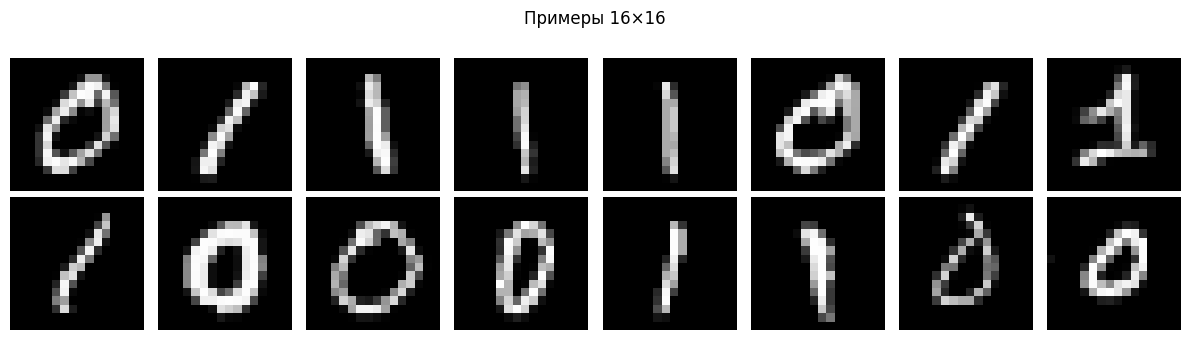

In [2]:
D_SIZE = 16
D      = D_SIZE ** 2   # 256

mnist = datasets.MNIST('./data', train=True, download=True)
raw   = mnist.data.float() / 255.0
mask  = (mnist.targets == 0) | (mnist.targets == 1)
imgs_raw = raw[mask]   # только 0 и 1

imgs = F.interpolate(imgs_raw.unsqueeze(1), size=(D_SIZE, D_SIZE),
                     mode='bilinear', align_corners=False).squeeze(1)
imgs = (imgs * 2 - 1).reshape(-1, D)   # (N, 256) в [-1, 1]
print(f'Картинок: {len(imgs)},  shape: {imgs.shape}')
print(f'диапазон: [{imgs.min():.1f}, {imgs.max():.1f}]  mean={imgs.mean():.3f}  std={imgs.std():.3f}')

def to_display(x):
    return (x.clamp(-1, 1) + 1) / 2

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for row, idx_start in enumerate([0, len(imgs)//2]):
    for j in range(8):
        img = to_display(imgs[idx_start + j]).reshape(D_SIZE, D_SIZE)
        axes[row, j].imshow(img, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        axes[row, j].axis('off')
plt.suptitle('Примеры 16×16', fontsize=12)
plt.tight_layout(); plt.show()

## 2. Расписание шума

alpha_bar[0]   = 0.9999  (почти 1 → мало шума)
alpha_bar[T-1] = 6.35e-03  (почти 0 → чистый шум)


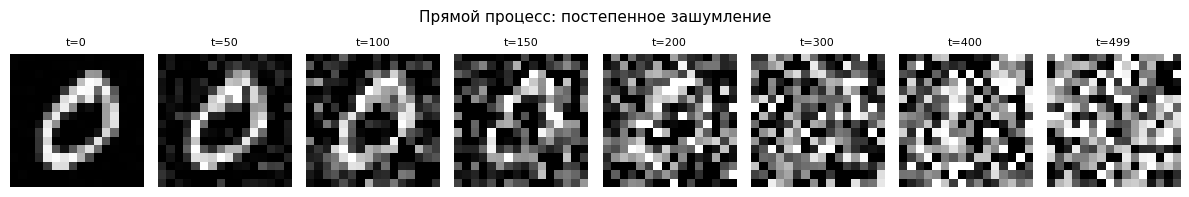

In [3]:
T        = 500
beta_min = 1e-4
beta_max = 0.02

betas      = torch.linspace(beta_min, beta_max, T).to(device)
alphas     = 1 - betas
alpha_bars = torch.cumprod(alphas, 0)
mus        = alpha_bars.sqrt()
sigmas     = (1 - alpha_bars).sqrt()

print(f'alpha_bar[0]   = {alpha_bars[0].item():.4f}  (почти 1 → мало шума)')
print(f'alpha_bar[T-1] = {alpha_bars[-1].item():.2e}  (почти 0 → чистый шум)')

# Проверка прямого процесса: x0 уже (D,) — плоский вектор
x0 = imgs[0].to(device)   # (256,)
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for j, t in enumerate([0, 50, 100, 150, 200, 300, 400, 499]):
    eps = torch.randn_like(x0)
    xt  = mus[t] * x0 + sigmas[t] * eps
    axes[j].imshow(to_display(xt.cpu()).reshape(D_SIZE, D_SIZE),
                   cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes[j].set_title(f't={t}', fontsize=8)
    axes[j].axis('off')
plt.suptitle('Прямой процесс: постепенное зашумление', fontsize=11)
plt.tight_layout(); plt.show()

## 3. Безусловный денойзер (простой MLP)

In [4]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        half  = dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half) / max(half - 1, 1))
        self.register_buffer('freqs', freqs)

    def forward(self, t):
        x = t.float().unsqueeze(-1) * self.freqs
        return torch.cat([x.sin(), x.cos()], dim=-1)


class Denoiser(nn.Module):
    """Безусловный денойзер: (x_noisy, t) → eps_pred."""
    def __init__(self, d=D, hidden=256, n_layers=4, t_dim=128):
        super().__init__()
        self.time_emb  = SinusoidalEmbedding(t_dim)
        self.input_proj = nn.Linear(d + t_dim, hidden)
        self.layers     = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(n_layers)])
        self.out        = nn.Linear(hidden, d)

    def forward(self, x, t):
        t_emb = self.time_emb(t)
        h = self.input_proj(torch.cat([x, t_emb], dim=-1))
        for layer in self.layers:
            h = h + F.silu(layer(h))   # residual
        return self.out(h)


model = Denoiser().to(device)
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

Параметров: 427,520


## 4. Обучение

step  2000/15000  loss: 0.2464
step  4000/15000  loss: 0.1855
step  6000/15000  loss: 0.1477
step  8000/15000  loss: 0.1278
step 10000/15000  loss: 0.1197
step 12000/15000  loss: 0.1156
step 14000/15000  loss: 0.1134


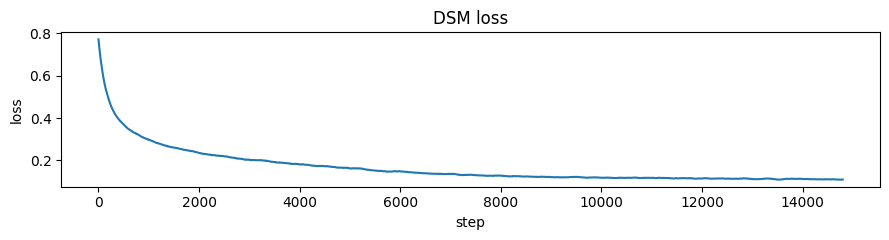

In [5]:
N_STEPS   = 15000
BATCH     = 128
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

imgs_dev = imgs.to(device)
N        = len(imgs_dev)

losses = []
for step in range(N_STEPS):
    idx  = torch.randint(N, (BATCH,))
    x0   = imgs_dev[idx]                          # (B, 256)
    t    = torch.randint(0, T, (BATCH,), device=device)
    eps  = torch.randn_like(x0)
    xt   = mus[t, None] * x0 + sigmas[t, None] * eps

    eps_hat = model(xt, t)
    loss    = F.mse_loss(eps_hat, eps)

    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
    if (step + 1) % 2000 == 0:
        print(f'step {step+1:5d}/{N_STEPS}  loss: {np.mean(losses[-200:]):.4f}')

w = 200
plt.figure(figsize=(9, 2.5))
plt.plot(np.convolve(losses, np.ones(w)/w, mode='valid'))
plt.xlabel('step'); plt.ylabel('loss'); plt.title('DSM loss')
plt.tight_layout(); plt.show()

## 5. Сэмплирование (DDPM)

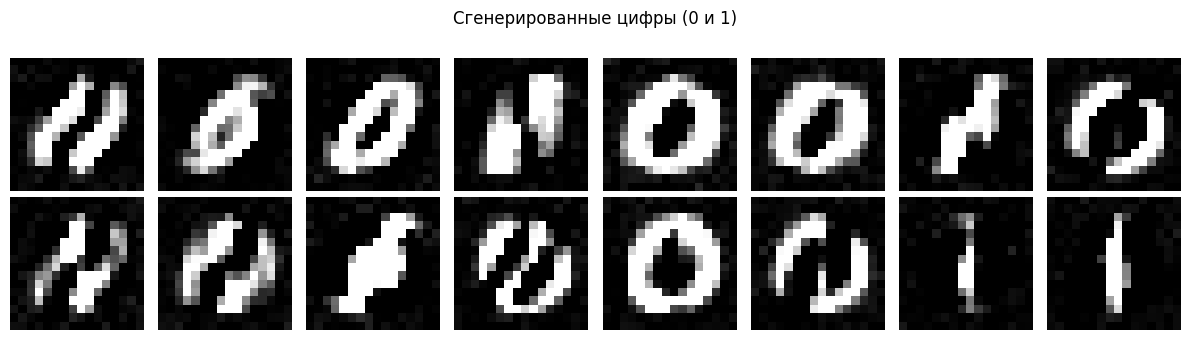

mean=0.224  std=0.373


In [6]:
@torch.no_grad()
def sample(n=16):
    model.eval()
    x = torch.randn(n, D, device=device)
    for t in reversed(range(T)):
        t_b     = torch.full((n,), t, dtype=torch.long, device=device)
        eps_hat = model(x, t_b)
        # DDPM обратный шаг
        x = (x - betas[t] / sigmas[t] * eps_hat) / alphas[t].sqrt()
        if t > 0:
            x = x + betas[t].sqrt() * torch.randn_like(x)
    return to_display(x.cpu())

torch.manual_seed(1)
samples = sample(16)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].reshape(D_SIZE, D_SIZE),
              cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax.axis('off')
plt.suptitle('Сгенерированные цифры (0 и 1)', fontsize=12)
plt.tight_layout(); plt.show()

print(f'mean={samples.mean():.3f}  std={samples.std():.3f}')